In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Dataset
from torchinfo import summary


ModuleNotFoundError: No module named 'torchinfo'

In [3]:
from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import MLP

## Deep Ritz Method - Energy Minimization

In [4]:
DAT = DATA(load=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")                      # TODO: implement gpu

Using device: cpu


In [5]:
in_size = DAT.train_in.shape[-1]
out_size = DAT.train_out.shape[-1]
h_size = [32, 32]

BATCH_SIZE = 16
LEARNING_RATE = 1e-3
n_epochs = 5000

In [6]:
trainDS = Dataset_(DAT.train_in, DAT.train_outST)
valDS = Dataset_(DAT.val_in, DAT.val_outST)
testDS = Dataset_(DAT.test_in, DAT.test_outST)

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=valDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
resNet1 = MLP(in_size, h_size, out_size, block="res", norm="layer").to(device)
resNet1.apply(weights_init)

opt = optim.Adam(resNet1.parameters(), lr=LEARNING_RATE, weight_decay=1e-5) 
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=30, min_delta=1e-4, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.7, patience=6, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

summary(mlp1, input_size=(BATCH_SIZE, in_size))

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [16, 201]                 --
├─Linear: 1-1                            [16, 32]                  22,880
├─LayerNorm: 1-2                         [16, 32]                  64
├─ReLU: 1-3                              [16, 32]                  --
├─ModuleList: 1-4                        --                        --
│    └─resBlock: 2-1                     [16, 32]                  --
│    │    └─Linear: 3-1                  [16, 64]                  2,112
│    │    └─LayerNorm: 3-2               [16, 64]                  128
│    │    └─ReLU: 3-3                    [16, 64]                  --
│    │    └─Linear: 3-4                  [16, 32]                  2,080
│    │    └─LayerNorm: 3-5               [16, 32]                  64
│    │    └─ReLU: 3-6                    [16, 32]                  --
│    └─resBlock: 2-2                     [16, 32]                  --
│   

In [15]:
mlp1, epoch, train_lossLog, val_lossLog = train_model("mpl", mlp1, lossf, n_epochs, opt, train_dataloader, 
                                                      val_dataloader=val_dataloader, scheduler=ReduceLR, 
                                                      earlyStop=None, verbose=10)

RuntimeError: Given normalized_shape=[32], expected input with shape [*, 32], but got input of size[16, 64]

In [ ]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [ ]:
test_outputs = predict_model("mlp", mlp1, test_dataloader)
test_outputs = standardize(test_outputs, DAT.outParams[0], DAT.outParams[1], mode=1)

In [ ]:
err = list(sum(abs(DAT.test_out - test_outputs)))
err.index(min(err)), err.index(max(err))

(2, 91)

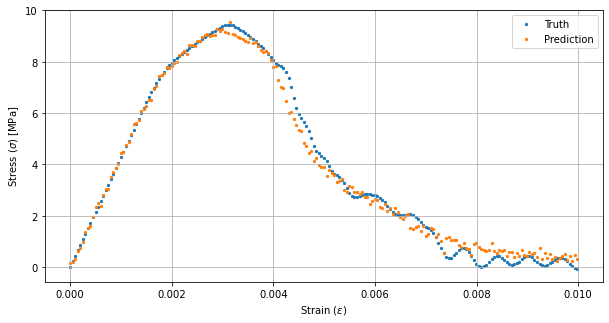

In [ ]:
plot_StressStrainOUT(DAT.perOUT, DAT.train_out, test_outputs, indx=1)